In [1]:
import torch 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re 
import matplotlib as mpl


In [42]:
LAYER_TYPES = ("layer_z", "tri_att_start", "tri_att_end")


def _key(layer_n: int, layer_type: str) -> str:
    return f"trunk_{layer_n}_{layer_type}"


def get_layer_ids(reps: dict, step: str, layer_type: str = "layer_z") -> list[int]:
    """Sorted trunk layer indices available for a given step/type."""
    pat = re.compile(rf"trunk_(\d+)_{layer_type}$")
    return sorted({int(m.group(1)) for k in reps[step] if (m := pat.match(k))})


def get_tensor(reps: dict, step: str, layer_n: int, layer_type: str = "layer_z") -> torch.Tensor:
    """Return the [N, N, D] tensor (batch squeezed) for a given step/layer."""
    return reps[step][_key(layer_n, layer_type)].squeeze(0)


def plot_layer(reps: dict, step: str, layer_n: int, layer_type: str = "layer_z",
               ax=None, cmap: str = "viridis"):
    """Heatmap of the L2 norm over the feature dim for a single layer."""
    m = get_tensor(reps, step, layer_n, layer_type).norm(dim=-1).cpu().numpy()
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4.5))
    sns.heatmap(m, ax=ax, cmap=cmap, square=True, xticklabels=False, yticklabels=False)
    ax.set_title(f"{step} | {layer_type} | layer {layer_n}")
    return ax


def plot_layers_grid(reps: dict, step: str, layer_type: str = "layer_z",
                     reduce: str = "norm", cmap: str = "viridis", ncols: int = 4):
    """Grid of heatmaps across all layers for a given step/type.

    reduce: 'norm' -> L2 over feature dim; 'mean' -> mean over feature dim.
    """
    layer_ids = get_layer_ids(reps, step, layer_type)
    mats = []
    for lid in layer_ids:
        t = get_tensor(reps, step, lid, layer_type)
        m = (t.norm(dim=-1) if reduce == "norm" else t.mean(dim=-1)).cpu().numpy()
        mats.append((lid, m))
    vmin = min(m.min() for _, m in mats)
    vmax = max(m.max() for _, m in mats)
    norm = plt.Normalize(vmin, vmax)

    nrows = (len(mats) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)
    for ax, (lid, m) in zip(axes.flat, mats):
        sns.heatmap(m, ax=ax, cbar=False, cmap=cmap, norm=norm, square=True,
                    xticklabels=False, yticklabels=False)
        ax.set_title(f"layer {lid}")
    for ax in axes.flat[len(mats):]:
        ax.axis("off")

    fig.subplots_adjust(right=0.88)
    cax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    fig.colorbar(sm, cax=cax).set_label(reduce)
    fig.suptitle(f"{step} | {layer_type} ({reduce})", fontsize=18)
    return fig, axes


def cosine_map(reps_a: dict, reps_b: dict, step: str, layer_n: int,
               layer_type: str = "layer_z") -> np.ndarray:
    """Per-pair cosine similarity [N, N] between two representations, clamped to [-1, 1]."""
    a = get_tensor(reps_a, step, layer_n, layer_type)
    b = get_tensor(reps_b, step, layer_n, layer_type)
    return torch.nn.functional.cosine_similarity(a, b, dim=-1).clamp(-1.0, 1.0).cpu().numpy()


def plot_cosine_grid(reps_a: dict, reps_b: dict, step: str,
                     layer_type: str = "layer_z", cmap: str = "magma", ncols: int = 4):
    """Grid of per-pair cosine-similarity heatmaps across layers."""
    layer_ids = get_layer_ids(reps_a, step, layer_type)
    mats = [(lid, cosine_map(reps_a, reps_b, step, lid, layer_type)) for lid in layer_ids]
    norm = plt.Normalize(-1.0, 1.0)

    nrows = (len(mats) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)
    for ax, (lid, m) in zip(axes.flat, mats):
        sns.heatmap(m, ax=ax, cbar=False, cmap=cmap, norm=norm, square=True,
                    xticklabels=False, yticklabels=False)
        ax.set_title(f"layer {lid}")
    for ax in axes.flat[len(mats):]:
        ax.axis("off")

    fig.subplots_adjust(right=0.88)
    cax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    fig.colorbar(sm, cax=cax).set_label("cosine similarity")
    fig.suptitle(f"cosine similarity | {step} | {layer_type}", fontsize=18)
    return fig, axes


def plot_cosine_trend(reps_a: dict, reps_b: dict, step: str,
                      layer_type: str = "layer_z", ax=None):
    """Scalar (mean/median over pairs) cosine similarity vs layer depth."""
    layer_ids = get_layer_ids(reps_a, step, layer_type)
    means, medians = [], []
    for lid in layer_ids:
        cs = cosine_map(reps_a, reps_b, step, lid, layer_type)
        means.append(cs.mean()); medians.append(np.median(cs))
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.plot(layer_ids, means, marker="o", label="mean")
    ax.plot(layer_ids, medians, marker="s", linestyle="--", label="median")
    ax.set_xlabel("trunk layer"); ax.set_ylabel("cosine similarity")
    ax.set_title(f"{step} | {layer_type}"); ax.grid(alpha=0.3); ax.legend()
    return ax, layer_ids, np.array(means), np.array(medians)


def plot_cosine_trend_by_type(reps_a: dict, reps_b: dict, step: str,
                              layer_types=LAYER_TYPES, ax=None, palette=None):
    """Overlay mean per-pair cosine similarity vs layer depth, one line per layer_type."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4.5))
    if palette is None:
        palette = dict(zip(layer_types, sns.color_palette("tab10", len(layer_types))))
    out = {}
    for lt in layer_types:
        layer_ids = get_layer_ids(reps_a, step, lt)
        if not layer_ids:
            continue
        means = np.array([cosine_map(reps_a, reps_b, step, lid, lt).mean() for lid in layer_ids])
        ax.plot(layer_ids, means, marker="o", color=palette[lt], label=lt)
        out[lt] = (np.array(layer_ids), means)
    ax.set_xlabel("trunk layer")
    ax.set_ylabel("mean cosine similarity")
    ax.set_title(f"{step} | cosine similarity by layer type")
    ax.grid(alpha=0.3)
    ax.legend()
    return ax, out


In [31]:
rep = torch.load("/Users/thomasbush/Downloads/esm_original/esmfold/A|protein|/hidden_reps.pt")

In [32]:
rep["step_0"].keys()

dict_keys(['trunk_0_tri_att_start', 'trunk_0_tri_att_end', 'trunk_0_layer_z', 'trunk_11_tri_att_start', 'trunk_11_tri_att_end', 'trunk_11_layer_z', 'trunk_23_tri_att_start', 'trunk_23_tri_att_end', 'trunk_23_layer_z', 'trunk_35_tri_att_start', 'trunk_35_tri_att_end', 'trunk_35_layer_z', 'trunk_47_tri_att_start', 'trunk_47_tri_att_end', 'trunk_47_layer_z'])

(<Figure size 2000x900 with 9 Axes>,
 array([[<Axes: title={'center': 'layer 0'}>,
         <Axes: title={'center': 'layer 11'}>,
         <Axes: title={'center': 'layer 23'}>,
         <Axes: title={'center': 'layer 35'}>],
        [<Axes: title={'center': 'layer 47'}>, <Axes: >, <Axes: >,
         <Axes: >]], dtype=object))

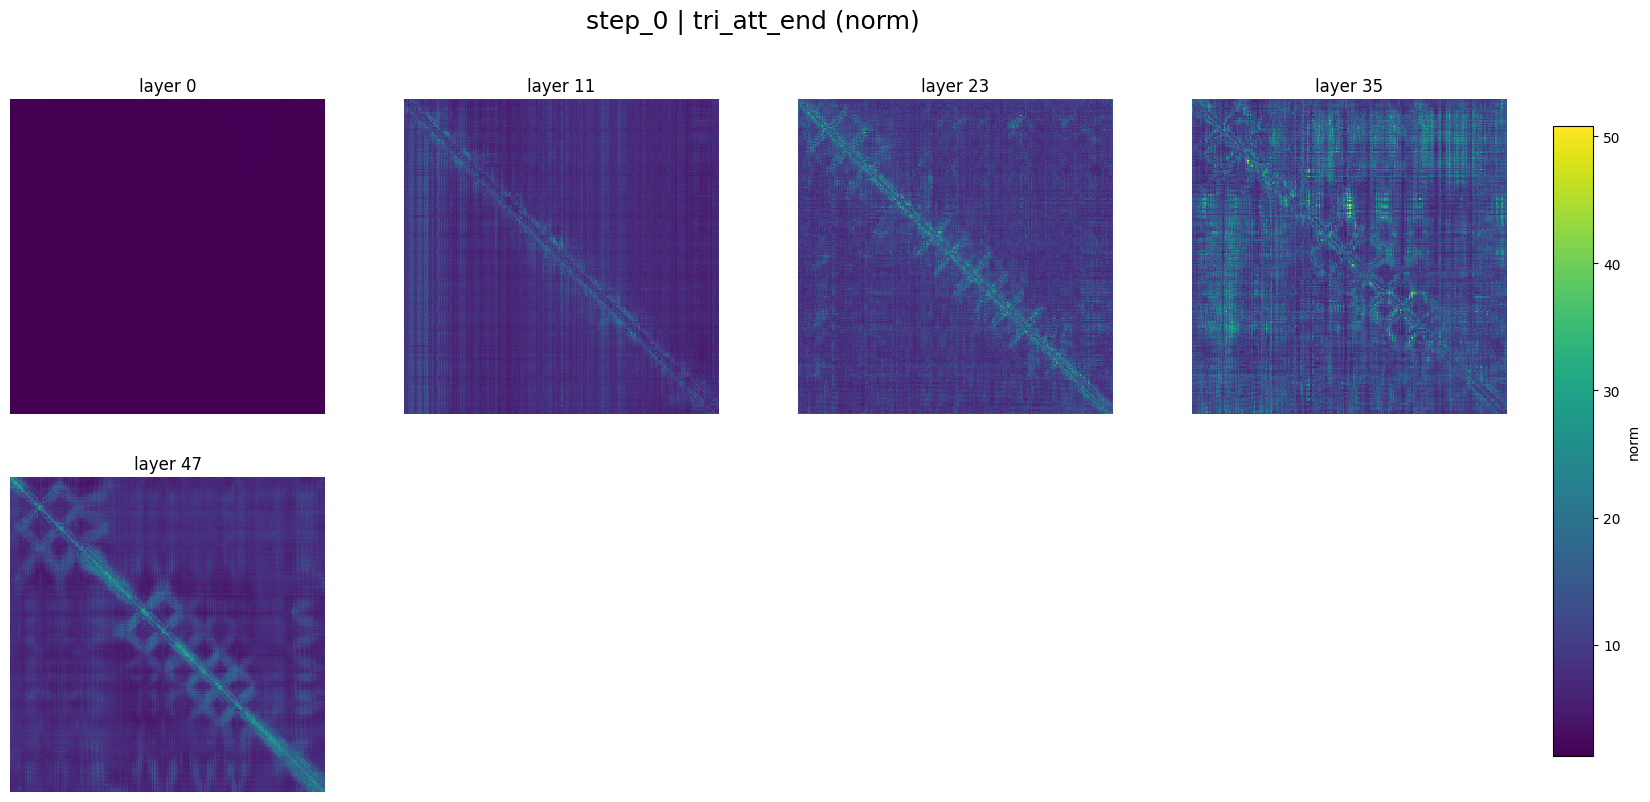

In [33]:
plot_layers_grid(rep, "step_0", "tri_att_end")

In [38]:
# rep 132:
rep_132 = torch.load("/Users/thomasbush/Downloads/esm132/132|protein|/hidden_reps.pt")

(<Figure size 2000x900 with 9 Axes>,
 array([[<Axes: title={'center': 'layer 0'}>,
         <Axes: title={'center': 'layer 11'}>,
         <Axes: title={'center': 'layer 23'}>,
         <Axes: title={'center': 'layer 35'}>],
        [<Axes: title={'center': 'layer 47'}>, <Axes: >, <Axes: >,
         <Axes: >]], dtype=object))

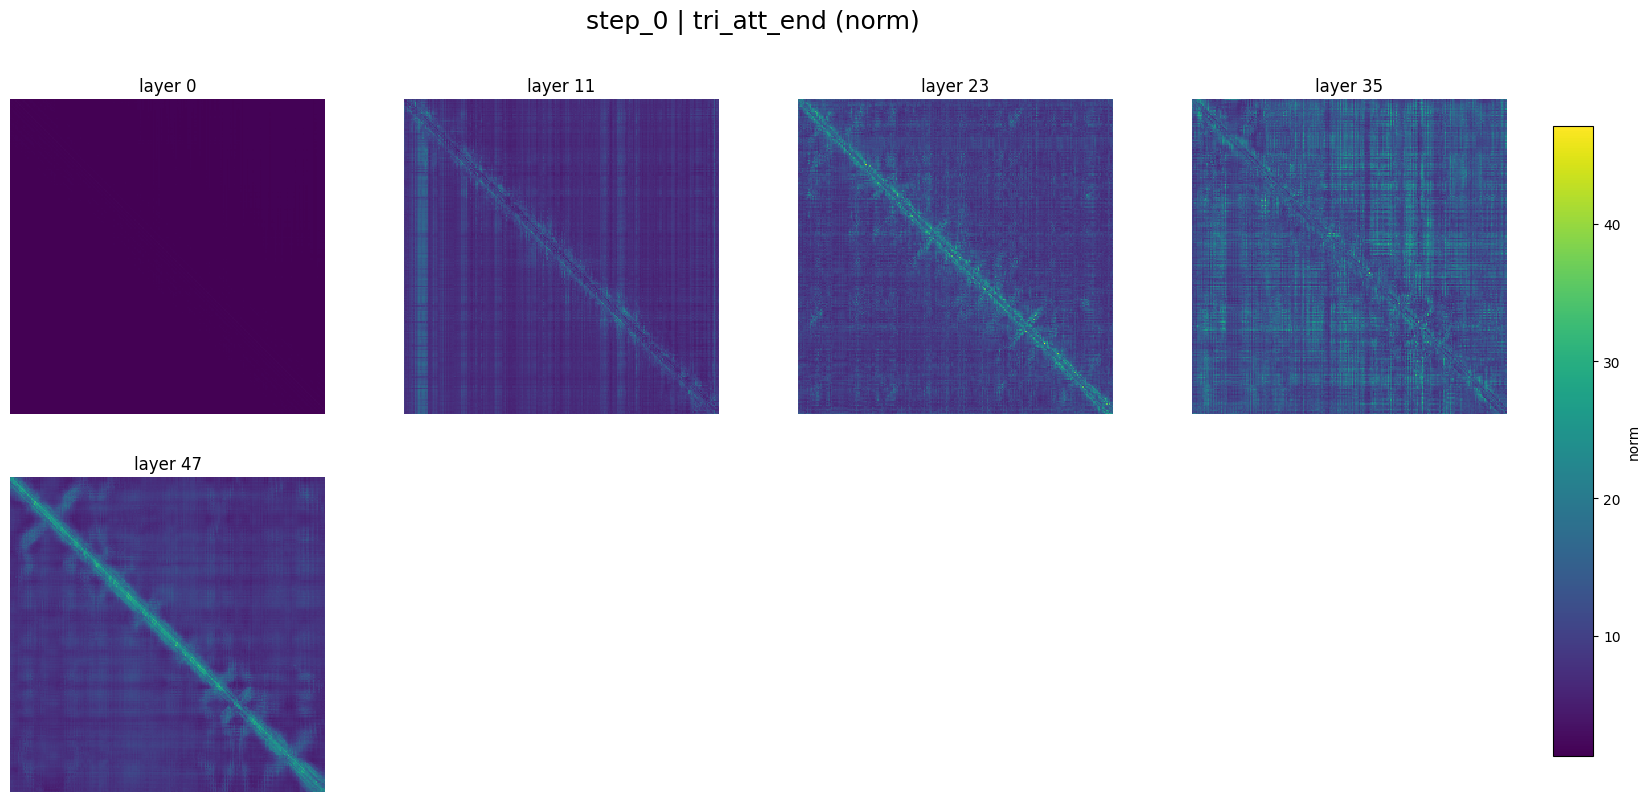

In [39]:
plot_layers_grid(rep_132, "step_0", "tri_att_end")

(<Figure size 2000x900 with 9 Axes>,
 array([[<Axes: title={'center': 'layer 0'}>,
         <Axes: title={'center': 'layer 11'}>,
         <Axes: title={'center': 'layer 23'}>,
         <Axes: title={'center': 'layer 35'}>],
        [<Axes: title={'center': 'layer 47'}>, <Axes: >, <Axes: >,
         <Axes: >]], dtype=object))

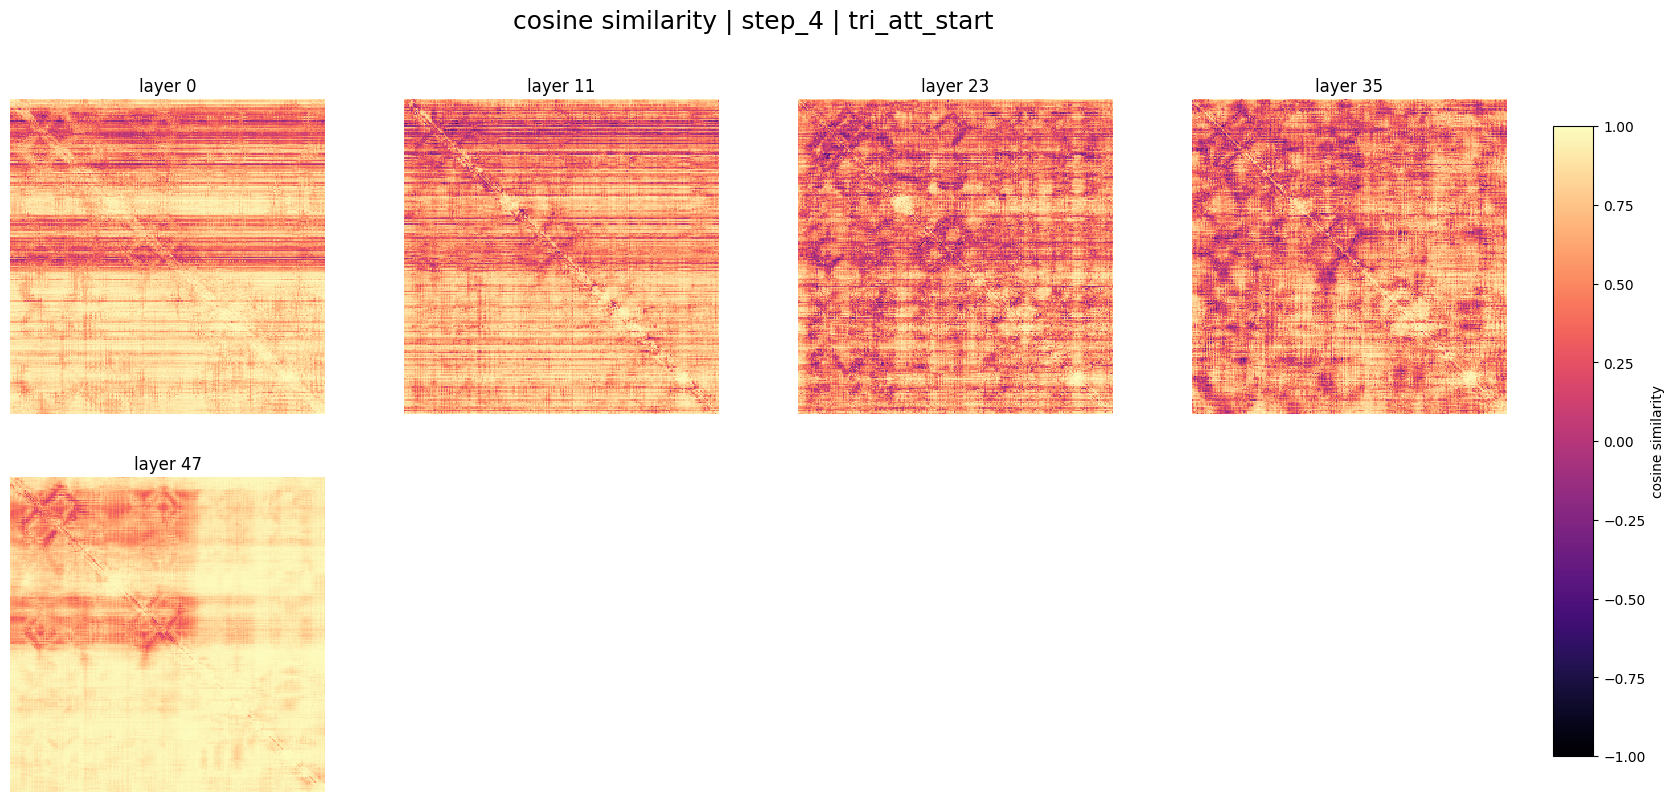

In [60]:
plot_cosine_grid(rep, rep_132, "step_4", "tri_att_start")